## USING A MACHINE LEARNING MODEL TO PREDICT CUSTOMER LIFETIME VALUE

In [16]:
# =========================================================
# IMPORT LIBRARIES & SETUP
# =========================================================

# Core & Data Manipulation
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning: Models & Tuning
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor

# Machine Learning: Preprocessing & Feature Selection
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Machine Learning: Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# System & Notebook Configs
import warnings
warnings.filterwarnings('ignore') # Hide noisy red warnings when training models

# Set default plot style for cleaner charts
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [17]:
df = pd.read_csv('Dataset/Cleaned_data/master_df.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 36 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CustomerID             52924 non-null  int64  
 1   Transaction_ID         52924 non-null  int64  
 2   Transaction_Date       52924 non-null  str    
 3   Month                  52924 non-null  str    
 4   Date                   52924 non-null  str    
 5   Week                   52924 non-null  str    
 6   Product_SKU            52924 non-null  str    
 7   Product_Description    52924 non-null  str    
 8   Product_Category       52924 non-null  str    
 9   ABC                    52924 non-null  str    
 10  Quantity               52924 non-null  int64  
 11  Avg_Price              52924 non-null  float64
 12  Delivery_Charges       52924 non-null  float64
 13  Revenue                52924 non-null  float64
 14  total_revenue          52924 non-null  float64
 15  Invoice      

## Time Split in CLV Prediction

**Purpose**: Split data by time so the model learns from the past and predicts the future.

**Steps**:
  - Convert `Transaction_Date` to datetime.
  - `end_date`: latest date.
  - `cutoff_date`: end_date - 90 days.
  - `cal_df`: data ≤ cutoff_date (training set).
  - `holdout_df`: data > cutoff_date (actual CLV test set).
  - `recent_df`: transactions in the 30 days before cutoff_date (recent behavior).

**Why it matters**: Ensures objective evaluation and captures recent trends.

In [18]:
# =========================================================
# TIME SPLIT
# =========================================================
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])

end_date = df['Transaction_Date'].max()
cutoff_date = end_date - pd.Timedelta(days=90)

cal_df = df[df['Transaction_Date'] <= cutoff_date].copy()
holdout_df = df[df['Transaction_Date'] > cutoff_date].copy()

# Recent window (30 days before cutoff)
recent_cutoff = cutoff_date - pd.Timedelta(days=30)

recent_df = cal_df[
    cal_df['Transaction_Date'] >= recent_cutoff
].copy()

## Base Features in CLV Prediction

**Purpose**: Create basic features for each customer from transaction data in the calibration period.

**Approach**: Group by `CustomerID` and aggregate metrics:
  - **Base RFM**: first_purchase, last_purchase, frequency, monetary_sum
  - **Purchase behavior**: total_quantity, unique_categories, avg_discount, coupon_usage
  - **Costs**: delivery_fee, offline/online spend, marketing spend
  - **Customer info**: Tenure_Months, Gender, Location, KMeans_Label

**Why it matters**: Convert transaction data into customer profiles for the model to learn from.

In [19]:
# =========================================================
# BASE FEATURES
# =========================================================
features = cal_df.groupby('CustomerID').agg(
    
    first_purchase=('Transaction_Date', 'min'),
    last_purchase=('Transaction_Date', 'max'),

    frequency_cal=('Transaction_Date', 'nunique'),
    monetary_sum=('total_revenue', 'sum'),

    total_quantity=('Quantity', 'sum'),
    unique_categories=('Product_Category', 'nunique'),

    avg_discount=('Discount_pct', 'mean'),
    coupon_usage_rate=('Is_Used_Coupon', 'mean'),

    total_delivery_fee=('Delivery_Charges', 'sum'),

    total_offline=('Offline_Spend', 'sum'),
    total_online=('Online_Spend', 'sum'),
    total_marketing=('Total_Marketing_Spend', 'sum'),

    Tenure_Months=('Tenure_Months', 'first'),

    Gender=('Gender', 'first'),
    Location=('Location', 'first'),

    KMeans_Label=('KMeans_Label', 'first')

).reset_index()

## RFM + Recent Features

**Core idea**: Build behavioral and customer profile metrics to predict CLV.
- **Recency (recency_cal)**: How long since the last purchase? → shows recent activity.
- **Customer Age (T_cal)**: How long has the customer been active? → older customers often have higher value.
- **Average Order Value (monetary_avg)**: How much does the customer spend per order on average? → measures order-level value.
- **Purchase Frequency (avg_order_interval)**: Average time between purchases → shows whether the customer buys regularly or intermittently.

**Recent behavior matters**: Recent actions are more important than older history. Customers can change habits over time.
- **freq_last30**: Number of purchases in the last 30 days → are they still buying regularly?
- **spend_last30**: Total spending in the last 30 days → recent investment level.
- **qty_last30**: Total quantity purchased recently → purchase intensity.

**Business impact**: These metrics help segment customers and predict future spend trends, especially to identify who is “hot” or cooling off.

In [20]:
# =========================================================
# RFM + CUSTOMER AGE FEATURES
# =========================================================
features['recency_cal'] = (
    cutoff_date - features['last_purchase']
).dt.days

features['T_cal'] = (
    cutoff_date - features['first_purchase']
).dt.days

features['monetary_avg'] = (
    features['monetary_sum'] /
    (features['frequency_cal'] + 1)
)

features['avg_order_interval'] = (
    features['T_cal'] /
    (features['frequency_cal'] + 1)
)

In [21]:
# =========================================================
# RECENT TREND FEATURES (LAST 30 DAYS)
# =========================================================
recent_features = recent_df.groupby('CustomerID').agg(
    
    freq_last30=('Transaction_Date', 'nunique'),
    spend_last30=('total_revenue', 'sum'),
    qty_last30=('Quantity', 'sum')

).reset_index()


features = pd.merge(
    features,
    recent_features,
    on='CustomerID',
    how='left'
)


# fill missing customers
recent_cols = [
    'freq_last30',
    'spend_last30',
    'qty_last30'
]

features[recent_cols] = (
    features[recent_cols]
    .fillna(0)
)

## Momentum Features - Capturing Change Trends

So far we have full historical purchase data for each customer. But there is one important question: **Is this customer buying more or less than before?**

Momentum features answer that by comparing recent behavior to historical averages.

### Purchase Momentum
- **Formula**: `freq_last30 / frequency_cal`
- **Meaning**: Ratio of recent purchase frequency to historical average
  - If = 1: customer buys at their usual pace
  - If > 1: customer is buying **more** recently (positive signal)
  - If < 1: customer is buying **less** recently (warning signal)

### Spend Momentum
- **Formula**: `spend_last30 / monetary_sum`
- **Meaning**: Ratio of recent spend to historical spend
  - Reflects trend: is the customer increasing or decreasing their budget?

### Why momentum matters
A customer may have strong history (long tenure, high spend), but if momentum is low, they are cooling off. Conversely, a newer customer with high momentum could be a rising star with strong potential.

In [22]:
# =========================================================
# MOMENTUM FEATURES
# =========================================================
features['purchase_momentum'] = (
    features['freq_last30'] /
    (features['frequency_cal'] + 1)
)

features['spend_momentum'] = (
    features['spend_last30'] /
    (features['monetary_sum'] + 1)
)

## Data Preparation for ML

**Drop date columns**: `first_purchase` and `last_purchase` have already been used to compute features (recency, T_cal). Keeping the raw dates would leak direct time information that the model does not need.

**Encode categorical variables**: Convert Gender, Location, and KMeans_Label into numeric one-hot features so models can learn from them. Drop one category per variable to avoid multicollinearity.

In [23]:
# =========================================================
# DROP DATE COLUMNS
# =========================================================
features = features.drop(
    columns=[
        'first_purchase',
        'last_purchase'
    ]
)

# =========================================================
# ENCODE CATEGORICAL
# =========================================================
features = pd.get_dummies(
    features,
    columns=[
        'Gender',
        'Location',
        'KMeans_Label'
    ],
    drop_first=True
)

## Create CLV Target

From the holdout period (90 days after cutoff_date), compute each customer's total spend. This becomes the actual CLV target that the model will predict. Merge with features and fill zeros for customers who did not purchase during that period.

In [24]:
# =========================================================
# TARGET (NEXT 90 DAYS CLV)
# =========================================================
target = holdout_df.groupby('CustomerID').agg(
    actual_clv_90d=('total_revenue', 'sum')
).reset_index()


ml_df = pd.merge(
    features,
    target,
    on='CustomerID',
    how='left'
)

ml_df['actual_clv_90d'] = (
    ml_df['actual_clv_90d']
    .fillna(0)
)

In [25]:
# =========================================================
# TRAIN / TEST SPLIT
# =========================================================
X = ml_df.drop(
    columns=[
        'CustomerID',
        'actual_clv_90d'
    ]
)

# giữ scale gốc trước, dễ interpret
y = ml_df['actual_clv_90d'].copy()

# Cap outliers (99th percentile)
upper = y.quantile(0.98)

y = np.clip(
    y,
    0,
    upper
)

print(f"Target capped at: {upper:.2f}")


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Target capped at: 6642.72


## Train & Evaluate CLV Models

After preparing the data and features, the next step is building and tuning machine learning models to predict CLV. This process includes three main steps:

---

### Step 1: Prepare Data for Modeling

**Split features and target**
- Separate `X` (all encoded features) and `y` (actual_clv_90d)
- Remove `CustomerID` (for tracking only) and the target label from X
- Keep y in its original scale for easier interpretation

**Handle outliers**
- Cap extreme CLV values at the 98th percentile
- **Why**: A few customers with extremely high spend (e.g., wholesale orders) can cause the model to learn non-representative patterns
- **Impact**: Reduces RMSE and improves R² by letting the model focus on the majority of customers

**Train/Test split**
- Split 80% train, 20% test with `random_state=42` for reproducibility
- Model learns from 80% training data
- Evaluate on 20% unseen test data to assess generalization

---

### Step 2: Configure & Compare 3 Prediction Models

We use **three tree-based models** because:
- Tree-based models handle imbalanced targets well
- They naturally capture feature interactions
- They are robust to outliers (after capping)
- Feature importance is easy to interpret

**1. Random Forest**
- **Description**: An ensemble of decision trees, each trained on a random subset of the data
- **Hyperparameter tuning**:
  - `n_estimators`: [100, 200, 300] - number of trees
  - `max_depth`: [4, 6, 8, 10, None] - depth of each tree
  - `min_samples_split`: [2, 5, 10] - minimum samples to split a node
  - `min_samples_leaf`: [1, 2, 4] - minimum samples in a leaf node
- **Strengths**: Fast, less likely to overfit, easy to train
- **Limitations**: Can be less effective on complex non-linear patterns

**2. Gradient Boosting**
- **Description**: Builds trees sequentially, where each tree corrects the errors of previous trees
- **Hyperparameter tuning**:
  - `n_estimators`: [100, 200, 300]
  - `learning_rate`: [0.01, 0.05, 0.1, 0.2]
  - `max_depth`: [3, 4, 5, 6]
  - `subsample`: [0.7, 0.8, 0.9, 1.0]
- **Strengths**: Usually delivers better accuracy, captures complex patterns
- **Limitations**: Slower to train, can overfit without careful tuning

**3. XGBoost (Extreme Gradient Boosting)**
- **Description**: An optimized gradient boosting algorithm with better regularization and performance
- **Hyperparameter tuning**:
  - Similar to GB but adds `colsample_bytree`: [0.7, 0.8, 0.9, 1.0]
- **Strengths**: Often the fastest and most accurate, handles outliers well
- **Limitations**: More complex, requires careful tuning

---

### Step 3: Train & Optimize

**Use RandomizedSearchCV**
- Instead of trying every combination (grid search), random search tests 15 random combinations
- **Benefit**: Saves significant compute time (hours reduced to minutes)
- **Cross-validation**: 3-fold CV splits the training set into 3 folds and validates sequentially
- **Scoring metric**: Optimize `neg_mean_absolute_error` (MAE), which is often better for imbalanced regression targets

**Per-model workflow**:
1. Fit RandomizedSearchCV on `X_train` and `y_train`
2. Extract `best_estimator_` (best parameter model)
3. Predict on `X_test`
4. Clamp predictions to avoid negative CLV
5. Calculate evaluation metrics:
   - **MAE**: Mean Absolute Error
   - **RMSE**: Root Mean Squared Error
   - **R² Score**: variance explained

**Feature importance analysis**
- After training, retrieve `feature_importances_` from the best model
- Sort the top 15 most important features
- This helps identify which variables most influence CLV
- Example: KMeans_Label, frequency, and spend_last30 are often top features

---

### Final result summary

Compare the three models on the test set:
- Rank by R² Score from highest to lowest
- Choose the model with the highest R² and lowest MAE for deployment
- XGBoost often performs best for CLV prediction

In [26]:
# =========================================================
# MODELS + PARAMETER SEARCH
# =========================================================
models_and_params = {

    "Random Forest": {
        "model": RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        ),
        "params": {
            'n_estimators': [100, 200, 300],
            'max_depth': [4, 6, 8, 10, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    },

    "Gradient Boosting": {
        "model": GradientBoostingRegressor(
            random_state=42
        ),
        "params": {
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'max_depth': [3, 4, 5, 6],
            'subsample': [0.7, 0.8, 0.9, 1.0]
        }
    },

    "XGBoost": {
        "model": XGBRegressor(
            random_state=42,
            n_jobs=-1
        ),
        "params": {
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'max_depth': [3, 4, 5, 6],
            'subsample': [0.7, 0.8, 0.9, 1.0],
            'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
        }
    }
}

In [27]:
# =========================================================
# TRAIN + EVALUATE
# =========================================================
results = []

print("\n--- START TRAINING ---")

for name, mp in models_and_params.items():

    print(f"\nTuning {name}...")

    random_search = RandomizedSearchCV(
        estimator=mp["model"],
        param_distributions=mp["params"],
        n_iter=15,
        scoring='neg_mean_absolute_error',
        cv=3,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )

    random_search.fit(
        X_train,
        y_train
    )

    best_model = random_search.best_estimator_
    # Feature importance (chỉ in cho XGBoost)
        
    importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': best_model.feature_importances_
    }).sort_values(
        by='importance',
        ascending=False
    )

    print("\nTop 15 Important Features:")
    print(importance.head(15))

    print(
        "Best Params:",
        random_search.best_params_
    )

    # Predict
    y_pred = best_model.predict(X_test)

    # no negative CLV
    y_pred = np.maximum(
        y_pred,
        0
    )

    # Metrics
    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    r2 = r2_score(
        y_test,
        y_pred
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

    print(
        f"MAE: {mae:.2f} | "
        f"RMSE: {rmse:.2f} | "
        f"R2: {r2:.4f}"
    )


# =========================================================
# FINAL RESULTS
# =========================================================
results_df = pd.DataFrame(
    results
).sort_values(
    by='R2 Score',
    ascending=False
)

print("\n--- FINAL RESULTS ---")
print(
    results_df.to_string(
        index=False
    )
)

print("\n---BEST MODEL---")
best_model = results_df.iloc[0]['Model']
print(best_model)


--- START TRAINING ---

Tuning Random Forest...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Top 15 Important Features:
               feature  importance
26      KMeans_Label_2    0.229101
25      KMeans_Label_1    0.156868
11         recency_cal    0.108406
1         monetary_sum    0.100956
6   total_delivery_fee    0.088310
9      total_marketing    0.044221
2       total_quantity    0.036824
7        total_offline    0.032699
13        monetary_avg    0.027066
8         total_online    0.024822
10       Tenure_Months    0.021925
5    coupon_usage_rate    0.020424
3    unique_categories    0.019389
12               T_cal    0.018825
14  avg_order_interval    0.018655
Best Params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 6}
MAE: 502.36 | RMSE: 987.61 | R2: 0.6259

Tuning Gradient Boosting...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Top 15 Important Features:
               feature  importance
26      KMe

## Model Validation

**Goal**:
Before using the Random Forest model to forecast future CLV, we need to validate its accuracy on the test set (data the model has not seen during training). Visualizing errors gives a more objective view of model performance.

**Chart meanings**:
1. **Scatter Plot (Actual vs. Predicted)**:
   - X axis is actual CLV, Y axis is predicted CLV.
   - The dashed red line (y=x) represents perfect prediction.
   - If the points are close to the red line, predictions are accurate. If points scatter far away, the model has large errors.

2. **Residuals Histogram**:
   - Residual = actual value - predicted value.
   - The dashed red line represents zero error.
   - A good model has a bell-shaped distribution centered around zero. If the peak is shifted left or right, the model has bias toward over- or under-prediction.

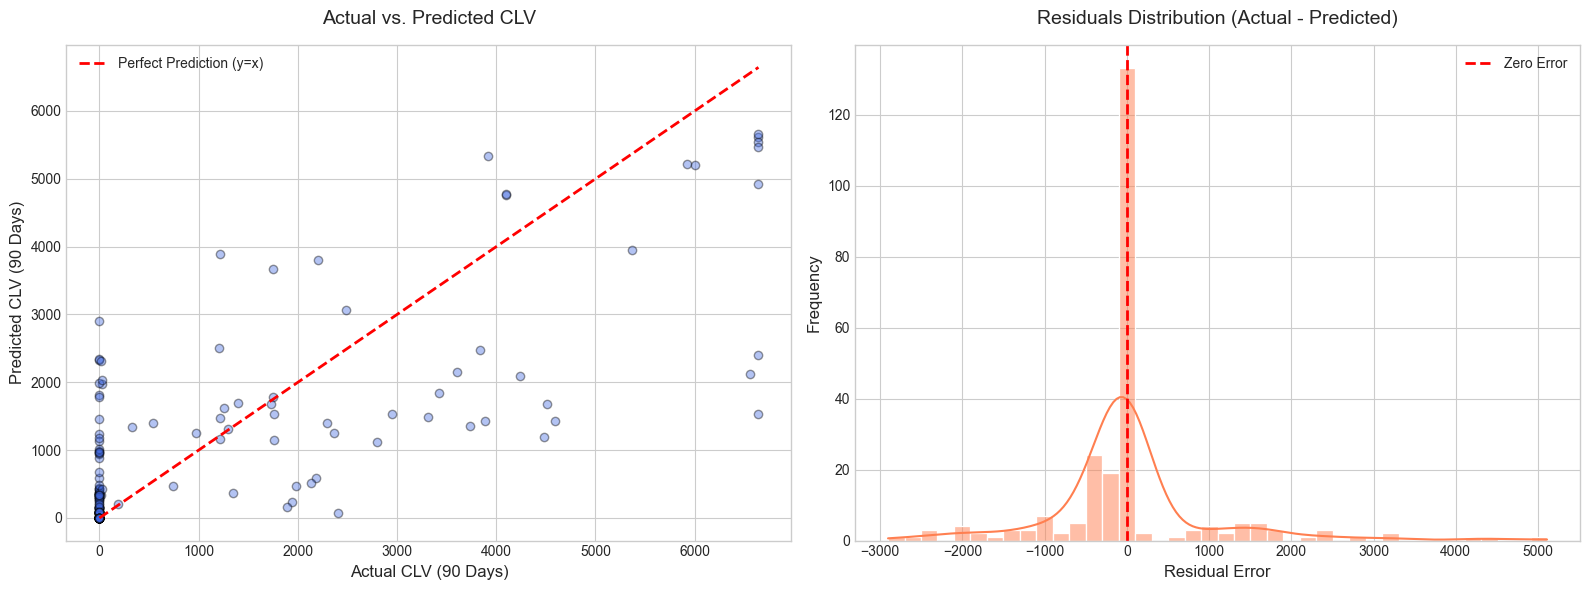

In [28]:
# =========================================================
# MODEL PREDICTION VALIDATION PLOTS
# =========================================================

# Reinitialize and retrain a model to avoid "not defined" errors
best_model_estimator = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
best_model_estimator.fit(X_train, y_train)

# Predict on the Test set for an objective evaluation
y_pred_test = best_model_estimator.predict(X_test)
y_pred_test = np.maximum(y_pred_test, 0)  # Do not allow negative CLV

# Calculate residuals
residuals = y_test - y_pred_test

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------
# 1. Scatter Plot: Actual vs Predicted
# ---------------------------------------------------------
axes[0].scatter(y_test, y_pred_test, alpha=0.4, color='royalblue', edgecolor='k')

# Plot the expected perfect prediction line: y = x
max_val = max(y_test.max(), y_pred_test.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect Prediction (y=x)')

axes[0].set_title('Actual vs. Predicted CLV', fontsize=14, pad=15)
axes[0].set_xlabel('Actual CLV (90 Days)', fontsize=12)
axes[0].set_ylabel('Predicted CLV (90 Days)', fontsize=12)
axes[0].legend()

# ---------------------------------------------------------
# 2. Residuals Histogram
# ---------------------------------------------------------
sns.histplot(residuals, kde=True, ax=axes[1], color='coral', bins=40)

# Draw a center line at zero
axes[1].axvline(x=0, color='r', linestyle='--', lw=2, label='Zero Error')

axes[1].set_title('Residuals Distribution (Actual - Predicted)', fontsize=14, pad=15)
axes[1].set_xlabel('Residual Error', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

From the validation plots, we can draw important conclusions about the Random Forest model's forecasting ability:

**1. Positive signal (basic prediction power):**
- The **residuals histogram** has a strong peak at zero error. This means the model predicts well for the majority of standard customers, with very low error. Overall, there is no large bias to one side.

**2. Model limitations (potential risks):**
The **scatter plot** reveals two typical issues in financial data for Random Forest:
- **Over-prediction for inactive customers (Actual = 0):** Many points with actual value 0 are predicted between $1,000 and $3,000. This is risky for marketing because it may lead to wasted retargeting budget for truly churned customers.
- **Under-prediction for super VIPs (whales):** For customers with very large actual spend (> $4,000), green points often fall below the perfect prediction line. This means the model underestimates their potential. Random Forest averages many trees, so it rarely predicts extreme values well.

**3. Recommendations & caveats for real use:**
If using these CLV forecasts for marketing campaigns, consider:
- **Combine with a churn model:** Do not trust CLV for customers with clear churn signals. Use a classification model to estimate return probability. If the chance of return is below 20%, set future CLV to 0.
- **Treat VIP risk carefully:** The top 10 VIP customers identified are likely valuable, but their true contribution may be much higher than the predicted amount.
- **Improvement path:** In future versions, try a two-stage model (classification for purchase probability + regression for spend) or customer lifetime models like Buy 'Til You Die (BTYD / BG-NBD) to address Random Forest weaknesses.

## Top 10 Customers with the Highest Predicted CLV

After training the model, we use the best model selected earlier to predict CLV for all customers in the training set.

**Approach**:
- Predict CLV for each customer in `X_train`
- Merge the results with CustomerID
- The top 10 customers are the highest predicted future value
- Use this list for:
  - **Retention**: focus on VIP care
  - **Marketing**: upsell/cross-sell
  - **Personalization**: offer premium treatment

In [29]:
# =========================================================
# FUTURE CLV PREDICTION 
# =========================================================

print("Recalculating features for future prediction...")

# 1. Use the latest timestamp as the reference (end_date of all data)
future_cutoff_date = df['Transaction_Date'].max()
future_recent_cutoff = future_cutoff_date - pd.Timedelta(days=30)

future_cal_df = df.copy()  # Use all historical data as history
future_recent_df = future_cal_df[future_cal_df['Transaction_Date'] >= future_recent_cutoff].copy()

# 2. Create base features
future_features = future_cal_df.groupby('CustomerID').agg(
    first_purchase=('Transaction_Date', 'min'),
    last_purchase=('Transaction_Date', 'max'),
    frequency_cal=('Transaction_Date', 'nunique'),
    monetary_sum=('total_revenue', 'sum'),
    total_quantity=('Quantity', 'sum'),
    unique_categories=('Product_Category', 'nunique'),
    avg_discount=('Discount_pct', 'mean'),
    coupon_usage_rate=('Is_Used_Coupon', 'mean'),
    total_delivery_fee=('Delivery_Charges', 'sum'),
    total_offline=('Offline_Spend', 'sum'),
    total_online=('Online_Spend', 'sum'),
    total_marketing=('Total_Marketing_Spend', 'sum'),
    Tenure_Months=('Tenure_Months', 'first'),
    Gender=('Gender', 'first'),
    Location=('Location', 'first'),
    KMeans_Label=('KMeans_Label', 'first')
).reset_index()

# 3. Build RFM + Customer Age features
future_features['recency_cal'] = (future_cutoff_date - future_features['last_purchase']).dt.days
future_features['T_cal'] = (future_cutoff_date - future_features['first_purchase']).dt.days
future_features['monetary_avg'] = (future_features['monetary_sum'] / (future_features['frequency_cal'] + 1))
future_features['avg_order_interval'] = (future_features['T_cal'] / (future_features['frequency_cal'] + 1))

# 4. Create recent features (last 30 days)
future_recent_features = future_recent_df.groupby('CustomerID').agg(
    freq_last30=('Transaction_Date', 'nunique'),
    spend_last30=('total_revenue', 'sum'),
    qty_last30=('Quantity', 'sum')
).reset_index()

future_features = pd.merge(future_features, future_recent_features, on='CustomerID', how='left')
recent_cols = ['freq_last30', 'spend_last30', 'qty_last30']
future_features[recent_cols] = future_features[recent_cols].fillna(0)

# 5. Build momentum features
future_features['purchase_momentum'] = (future_features['freq_last30'] / (future_features['frequency_cal'] + 1))
future_features['spend_momentum'] = (future_features['spend_last30'] / (future_features['monetary_sum'] + 1))

# Drop datetime columns
future_features = future_features.drop(columns=['first_purchase', 'last_purchase'])

# 6. One-hot encoding
future_features = pd.get_dummies(future_features, columns=['Gender', 'Location', 'KMeans_Label'], drop_first=True)

# Ensure X_future matches X_train exactly (handle missing dummy columns)
X_future = future_features.drop(columns=['CustomerID'])
for col in X_train.columns:
    if col not in X_future.columns:
        X_future[col] = 0
X_future = X_future[X_train.columns]  # Reorder columns to match model training

print("Starting CLV prediction for the next 90 days from the latest date...")

# 7. FUTURE PREDICTION
true_future_predictions = best_model_estimator.predict(X_future)
true_future_predictions = np.maximum(true_future_predictions, 0)  # Do not allow negative values

# 8. Build Top 10 future customers list
true_top_customers = future_features[['CustomerID']].copy()
true_top_customers['Predicted_Future_CLV'] = true_future_predictions

true_top_10 = true_top_customers.nlargest(10, 'Predicted_Future_CLV').reset_index(drop=True)
true_top_10.columns = ['Customer ID', 'Predicted CLV (Next 90 Days From Now)']

print("\n" + "="*70)
print("TOP 10 VIP CUSTOMERS (PREDICTED FOR THE NEXT 90 DAYS)")
print("="*70)
print(true_top_10.to_string(index=False))
print("="*70)
print(f"\nTotal expected CLV from these Top 10 customers: ${true_top_10['Predicted CLV (Next 90 Days From Now)'].sum():,.2f}")

Recalculating features for future prediction...
Starting CLV prediction for the next 90 days from the latest date...

TOP 10 VIP CUSTOMERS (PREDICTED FOR THE NEXT 90 DAYS)
 Customer ID  Predicted CLV (Next 90 Days From Now)
       14606                            5046.976425
       14911                            4969.944593
       15311                            4379.451142
       17841                            4376.516371
       12748                            3753.424585
       15039                            3573.960919
       13777                            3131.118479
       15808                            3105.236162
       17337                            3075.102489
       14688                            3009.704214

Total expected CLV from these Top 10 customers: $38,421.44


## Customer Segmentation Based on CLV

**Goal**:
Instead of treating all customers the same, we use the predicted CLV from the previous step to split customers into strategic groups. This helps optimize marketing spend and personalize the customer experience.

**Segmentation method (percentile ranking):**
We use percentile ranking based on predicted CLV to divide customers into three main groups:
- 🌟 **VIP (Top 20%)**: The top 20% of customers by future value. This group needs special care (retention & loyalty programs).
- 🤝 **Loyal (20% - 50%)**: A solid middle group with growth potential. The goal is to stimulate cross-sell and upsell.
- 👥 **Standard (Bottom 50%)**: The bottom 50% with the lowest predicted value. Use low-cost automated marketing for this group.

**Visualization**:
- **Donut Chart**: Shows Pareto-like dynamics—the minority VIP group may contribute most of the future revenue.
- **Bar Chart**: Shows average predicted spend per customer for each group, helping set budget levels for acquisition or retention campaigns (CAC < CLV).

CUSTOMER SEGMENTATION ANALYSIS BASED ON CLV:
              Segment  Customer_Count     Total_CLV  Average_CLV  CLV_Contribution_Pct
        VIP (Top 20%)             243 523923.483554  2156.063718             81.078007
    Loyal (20% - 50%)             363 117160.203818   322.755382             18.130731
Standard (Bottom 50%)             605   5113.110304     8.451422              0.791262


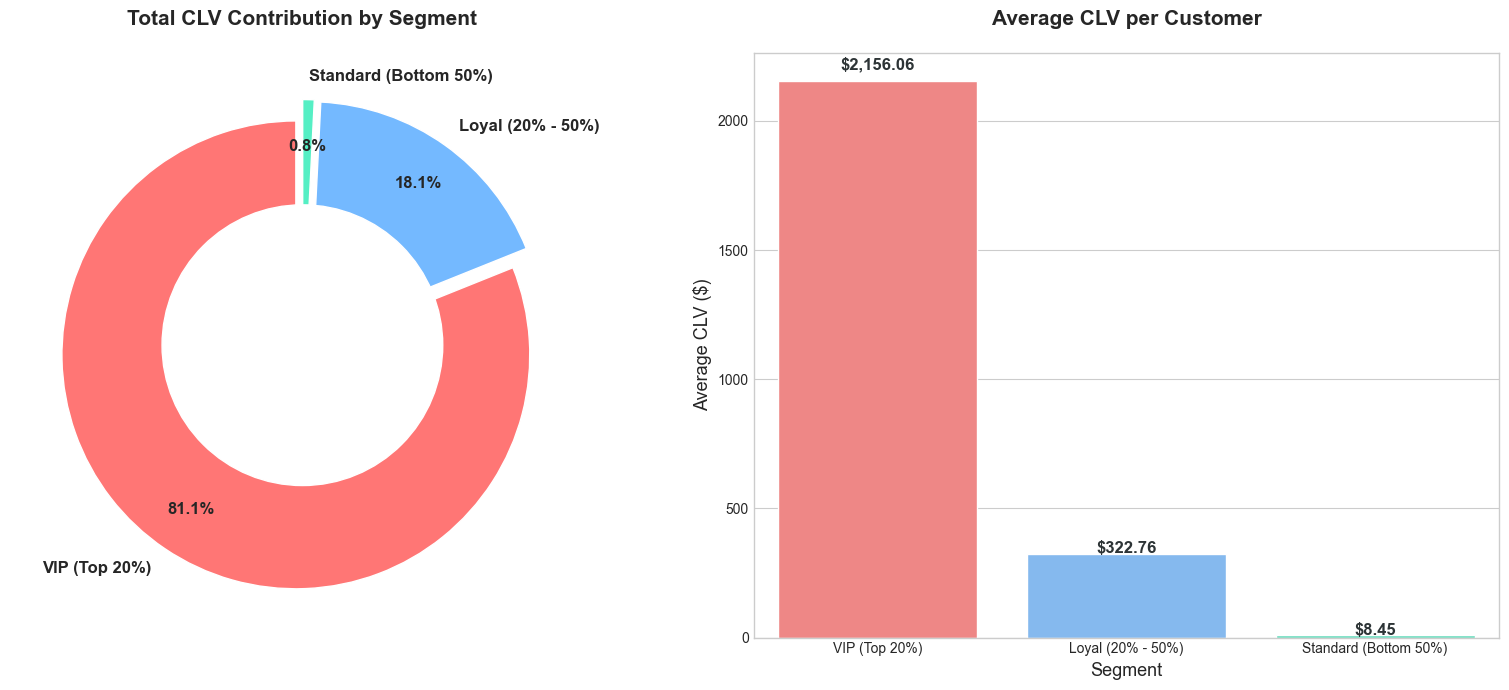

In [30]:
# =========================================================
# 16. Customer Segmentation based on CLV
# =========================================================

# Dự báo CLV cho toàn bộ khách hàng và tạo dataframe
y_pred_all = best_model_estimator.predict(X)
y_pred_all = np.maximum(y_pred_all, 0)
top_customers = ml_df.copy()
top_customers['predicted_clv'] = y_pred_all
# ---------------------------------------------------------------

# Extract CustomerID and predicted_clv (CLV)
clv_df = top_customers[['CustomerID', 'predicted_clv']].copy()
clv_df.rename(columns={'predicted_clv': 'CLV'}, inplace=True)

# ---------------------------------------------------------
# Customer Segmentation based on CLV
# ---------------------------------------------------------
# Use the rank function to rank customers, then divide into 3 groups:
# - VIP (Top 20% highest)
# - Loyal (20% to 50%)
# - Standard (Bottom 50%)

clv_df['Rank'] = clv_df['CLV'].rank(pct=True)

def assign_clv_segment(rank):
    if rank >= 0.8:
        return 'VIP (Top 20%)'
    elif rank >= 0.5:
        return 'Loyal (20% - 50%)'
    else:
        return 'Standard (Bottom 50%)'

clv_df['Segment'] = clv_df['Rank'].apply(assign_clv_segment)

# ---------------------------------------------------------
# Segment Analysis
# ---------------------------------------------------------
# Calculate total customers, total CLV, and average CLV for each segment
segment_analysis = clv_df.groupby('Segment').agg(
    Customer_Count=('CustomerID', 'count'),
    Total_CLV=('CLV', 'sum'),
    Average_CLV=('CLV', 'mean')
).reset_index()

# Calculate the percentage contribution of CLV for each segment to the total expected revenue
total_clv_sum = segment_analysis['Total_CLV'].sum()
segment_analysis['CLV_Contribution_Pct'] = (segment_analysis['Total_CLV'] / total_clv_sum) * 100

# Sort the segments from highest to lowest
sort_mapping = {'VIP (Top 20%)': 1, 'Loyal (20% - 50%)': 2, 'Standard (Bottom 50%)': 3}
segment_analysis['Sort'] = segment_analysis['Segment'].map(sort_mapping)
segment_analysis = segment_analysis.sort_values('Sort').drop('Sort', axis=1)

print("CUSTOMER SEGMENTATION ANALYSIS BASED ON CLV:")
print("="*85)
print(segment_analysis.to_string(index=False))
print("="*85)

# ---------------------------------------------------------
# Visualize the contribution of each segment
# ---------------------------------------------------------
plt.figure(figsize=(16, 7))
sns.set_style("whitegrid")
colors = ['#ff7675', '#74b9ff', '#55efc4']

# 1. Donut Chart: CLV Contribution Percentage (%)
ax1 = plt.subplot(1, 2, 1)
explode = (0.05, 0.05, 0.05)
plt.pie(segment_analysis['Total_CLV'], 
        labels=segment_analysis['Segment'], 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=colors, 
        explode=explode, 
        pctdistance=0.80, 
        textprops={'fontsize': 12, 'weight': 'bold'})

# Draw a white circle in the center to create a Donut Chart effect
centre_circle = plt.Circle((0,0), 0.60, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Total CLV Contribution by Segment', fontsize=15, weight='bold', pad=20)

# 2. Bar Chart: Average CLV per customer in the segment
ax2 = plt.subplot(1, 2, 2)
sns.barplot(x='Segment', y='Average_CLV', hue='Segment', data=segment_analysis, palette=colors, ax=ax2, legend=False)

# Print specific amounts on top of each bar
for i, v in enumerate(segment_analysis['Average_CLV']):
    ax2.text(i, v + (v*0.02), f'${v:,.2f}', ha='center', fontsize=12, fontweight='bold', color='#2d3436')

plt.title('Average CLV per Customer', fontsize=15, weight='bold', pad=20)
plt.xlabel('Segment', fontsize=13)
plt.ylabel('Average CLV ($)', fontsize=13)

plt.tight_layout()
plt.show()


## Forecasted LTV Opportunity Report & Strategic Recommendations

### Insights

**Predicted VIP power:** Unlike looking at historical revenue, the model shows that only 20% of current customers hold about **81.1% of future cash flow**. This is “almost guaranteed revenue” if we do not upset them in the next quarter.

**Expected value gap:** The model predicts strong polarization in future spending. In the next 90 days, a VIP customer is expected to contribute around $2,156, while a bottom-half Standard customer is forecast to nearly “hibernate” or churn with spend under $8.45.
* **Opportunity cost warning for Standard:** The bar chart sounds an alarm: 50% of the customer database (the Standard group) has almost exhausted its exploitable potential. Continuing to spend equal remarketing budget on this group for the next 90 days will likely produce negative ROI.

### Actionable Recommendations

Based on the principle “invest in the future, cut losses in the present,” the 90-day action plan should include:

**💎 VIP Customers (Protect expected revenue)**
- **Goal:** Make sure the $523,923 (81.1%) forecast becomes real revenue. Avoid any customer service issues for this group.
- **Actions:**
  - Launch a “VIP Care” campaign before the 90-day window ends: call them, send premium e-vouchers with no strings attached.
  - Apply a whitelist: exclude this group from deep discount clearance campaigns to protect their premium perception.

**🤝 Loyal Customers (Stimulate future growth)**
- **Goal:** The forecast of $322 per customer shows they still have demand but have not peaked. We need campaigns to push actual spend above the forecast.
- **Actions:**
  - Trigger personalized product recommendations based on past purchases.
  - Run flash sales or bundle offers specifically for this group to increase average order value.

**👥 Standard Customers (Reallocate budget)**
- **Goal:** Stop wasting marketing spend on customers with low predicted future potential.
- **Actions:**
  - Immediately exclude this group from paid ad campaigns (Facebook/Google Ads) for the next quarter.
  - Move them into low-frequency email/SMS drip campaigns for low-cost reactivation.
  - **Budget shift:** Reinvest the savings into acquiring new customers that resemble the VIP profile.